# Hierarchical IDS — M1 Routing Gate Validation

This notebook validates **M1 as a probabilistic routing gate** within a hierarchical Intrusion Detection System (IDS) for power grid protection.

All models are **pre-trained offline** and are used here **for inference only**. No model training or parameter learning is performed in this notebook.

## Purpose

The goal is to assess whether M1’s output probabilities can reliably support **attack vs non-attack routing**, rather than final classification.

This notebook:
- Analyses score separation between attack and non-attack samples
- Selects a routing threshold (τ) using validation data
- Evaluates routing behaviour on a held-out test set

## Scope

- M1 routes samples to:
  - **M3** (attack branch)
  - **M2** (non-attack branch)
- Threshold selection prioritises **high attack recall**
- Downstream models (M2–M6) are not evaluated here

## Exclusions

- No fallback logic
- No end-to-end hierarchical inference

These are handled in later notebooks.

In [1]:
# ------------------------------------------------------------
# 1) IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------
# This cell imports only utility libraries needed for
# loading models, handling data, and evaluating system behavior.
# No training-related imports are used here.

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc
)

In [2]:
# ------------------------------------------------------------
# 2) LOAD PRE-TRAINED MODELS (NO TRAINING HERE)
# ------------------------------------------------------------
# All hierarchical classifiers (M1–M6) are trained offline
# in the training notebook and loaded here for system use.
M1 = joblib.load("../models/M1.joblib")
M2 = joblib.load("../models/M2.joblib")
M3 = joblib.load("../models/M3.joblib")
M4 = joblib.load("../models/M4.joblib")
M5 = joblib.load("../models/M5.joblib")
M6 = joblib.load("../models/M6.joblib")

# M1 output convention: index 0 corresponds to "Attack"
ATTACK_LABEL_IDX = 0

In [3]:
# ------------------------------------------------------------
# 3) LABEL MAPS (STATIC METADATA)
# ------------------------------------------------------------
# These dictionaries map model output indices to human-readable
# scenario labels. They are used only for interpretation and
# reporting, not for training or routing decisions.

M2_LABELS = {
    0: "SLG Fault L1 (10–19%)",
    1: "SLG Fault L1 (20–79%)",
    2: "SLG Fault L1 (80–90%)",
    3: "SLG Fault L2 (10–19%)",
    4: "SLG Fault L2 (20–79%)",
    5: "SLG Fault L2 (80–90%)",
    6: "Line Maintenance (L1)",
    7: "Line Maintenance (L2)",
    8: "Normal Operation"
}

M3_LABELS = {
    0: "Data Injection",
    1: "Remote Tripping",
    2: "Relay Setting Change"
}

M4_LABELS = {
    0: "DI L1 10–19%",
    1: "DI L1 20–79%",
    2: "DI L1 80–90%",
    3: "DI L2 10–19%",
    4: "DI L2 20–79%",
    5: "DI L2 80–90%"
}

M5_LABELS = {
    0: "RT R1",
    1: "RT R2",
    2: "RT R3",
    3: "RT R4",
    4: "RT R1 & R2",
    5: "RT R3 & R4"
}

M6_LABELS = {
    0: "RSC R1 (L1 Fault)",
    1: "RSC R1 (High Fault)",
    2: "RSC R2 (Low Fault)",
    3: "RSC R2 (Mid Fault)",
    4: "RSC R2 (High Fault)",
    5: "RSC R3 (Low Fault)",
    6: "RSC R3 (Mid Fault)",
    7: "RSC R3 (High Fault)",
    8: "RSC R4 (Low Fault)",
    9: "RSC R4 (High Fault)",
    10: "RSC R1 & R2",
    11: "RSC R1 & R2 (High)",
    12: "RSC R3 & R4",
    13: "RSC R3 & R4 (High)",
    14: "RSC Maint R1 & R2",
    15: "RSC Maint R1 & R2 (Alt)"
}


In [4]:
# ------------------------------------------------------------
# 4) LOAD DATA (SAME FEATURES AS TRAINING)
# ------------------------------------------------------------
# The dataset is loaded using the same preprocessed feature set
# as used during model training. No feature engineering or
# preprocessing is performed here.

df = pd.read_csv("../data/merged/multi_class_dataset_clean_FULL.csv")

FEATURE_COLS = [c for c in df.columns if c not in ["marker", "label", "label_name"]]
X = df[FEATURE_COLS]
y = df["marker"]  # system-level scenario marker (int)

In [5]:
# ------------------------------------------------------------
# 5) VALIDATION / TEST SPLIT (SYSTEM LEVEL)
# ------------------------------------------------------------
# This split is used only for system evaluation:
# - Validation set: selection of routing threshold τ
# - Test set: final end-to-end system evaluation
# No training split is required because models are pre-trained.

X_val, X_test, y_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [6]:
# ------------------------------------------------------------
# 6) SYSTEM-LEVEL GROUND TRUTH FOR M1 GATE
# ------------------------------------------------------------
# M1 performs ONLY binary routing:
#   Attack      → route to M3
#   Non-Attack  → route to M2
#
# Non-attack includes:
#   - SLG faults
#   - Maintenance
#   - Normal operation
#
# Attack includes all remaining scenario IDs
# ------------------------------------------------------------

# Define scenario IDs (must match training notebook)
SLG_IDS    = [1, 2, 3, 4, 5, 6]     # system-level ground faults
MAINT_IDS  = [13, 14]              # maintenance
NORMAL_IDS = [41]                  # normal operation

NON_ATTACK_IDS = SLG_IDS + MAINT_IDS + NORMAL_IDS

# -----------------------------
# Validation set ground truth
# -----------------------------
is_attack_val = ~y_val.isin(NON_ATTACK_IDS).to_numpy()
is_non_attack_val = ~is_attack_val

# -----------------------------
# Test set ground truth (for later evaluation)
# -----------------------------
is_attack_test = ~y_test.isin(NON_ATTACK_IDS).to_numpy()
is_non_attack_test = ~is_attack_test

# Sanity check
print("Validation set:")
print("  Attacks:", is_attack_val.sum())
print("  Non-attacks:", is_non_attack_val.sum())

print("\nTest set:")
print("  Attacks:", is_attack_test.sum())
print("  Non-attacks:", is_non_attack_test.sum())

Validation set:
  Attacks: 44531
  Non-attacks: 18170

Test set:
  Attacks: 11132
  Non-attacks: 4544


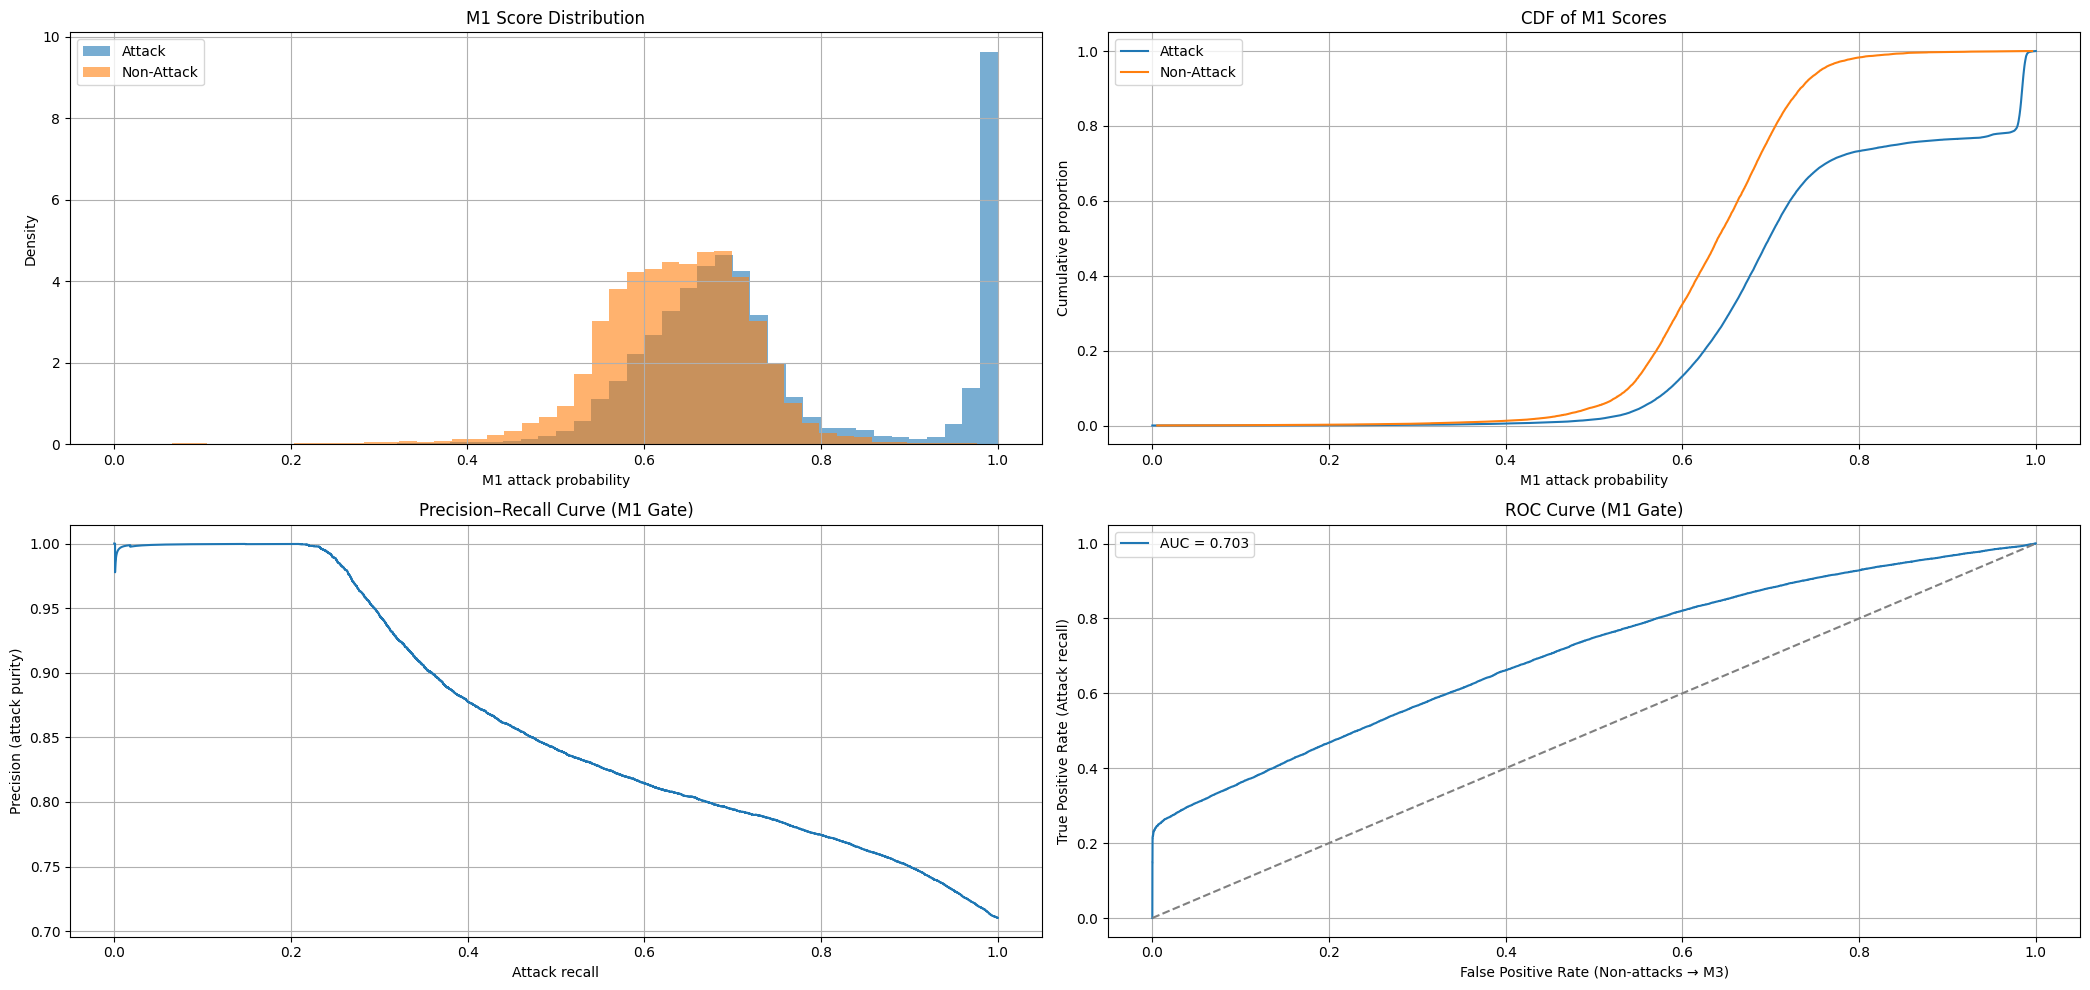


Diagnostic interpretation:
- Substantial overlap exists between attack and non-attack score distributions.
- No single threshold cleanly separates the two classes.
- M1 is therefore unsuitable as a final classifier.
- Instead, M1 is used as a conservative routing gate.
- The routing threshold τ is selected to guarantee high attack recall,
  accepting false positives that are resolved by downstream models.


In [7]:
# ------------------------------------------------------------
# 7) M1 SCORE SEPARATION & GATE FEASIBILITY CHECK (VALIDATION SET)
# ------------------------------------------------------------
# Purpose:
# This cell evaluates whether M1 is suitable as a *routing gate*.
# M1 is NOT treated as a classifier here.
#
# The goal is to assess:
#  - score overlap between attack and non-attack samples
#  - feasibility of recall-controlled thresholding
#
# These diagnostics justify:
#  - conservative routing (high attack recall)
#  - acceptance of false positives handled downstream
# ------------------------------------------------------------

# M1 attack probabilities on validation set
p_attack = M1.predict_proba(X_val)[:, ATTACK_LABEL_IDX]

# Separate scores by true routing label
attack_scores = p_attack[is_attack_val]
non_attack_scores = p_attack[is_non_attack_val]

# Create 2x2 diagnostic view
fig, axes = plt.subplots(2, 2, figsize=(21, 10))

# ------------------------------------------------------------
# (1) Score distribution (Histogram)
# ------------------------------------------------------------
axes[0, 0].hist(
    attack_scores, bins=50, alpha=0.6, density=True, label="Attack"
)
axes[0, 0].hist(
    non_attack_scores, bins=50, alpha=0.6, density=True, label="Non-Attack"
)
axes[0, 0].set_title("M1 Score Distribution")
axes[0, 0].set_xlabel("M1 attack probability")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()
axes[0, 0].grid(True)

# ------------------------------------------------------------
# (2) CDF of scores
# ------------------------------------------------------------
for scores, label in [
    (attack_scores, "Attack"),
    (non_attack_scores, "Non-Attack")
]:
    sorted_scores = np.sort(scores)
    cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
    axes[0, 1].plot(sorted_scores, cdf, label=label)

axes[0, 1].set_title("CDF of M1 Scores")
axes[0, 1].set_xlabel("M1 attack probability")
axes[0, 1].set_ylabel("Cumulative proportion")
axes[0, 1].legend()
axes[0, 1].grid(True)

# ------------------------------------------------------------
# (3) Precision–Recall curve
# ------------------------------------------------------------
precision, recall, _ = precision_recall_curve(is_attack_val, p_attack)

axes[1, 0].plot(recall, precision)
axes[1, 0].set_title("Precision–Recall Curve (M1 Gate)")
axes[1, 0].set_xlabel("Attack recall")
axes[1, 0].set_ylabel("Precision (attack purity)")
axes[1, 0].grid(True)

# ------------------------------------------------------------
# (4) ROC curve
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(is_attack_val, p_attack)
roc_auc = auc(fpr, tpr)

axes[1, 1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[1, 1].set_title("ROC Curve (M1 Gate)")
axes[1, 1].set_xlabel("False Positive Rate (Non-attacks → M3)")
axes[1, 1].set_ylabel("True Positive Rate (Attack recall)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Interpretation (System Design Rationale)
# ------------------------------------------------------------
print(
    "\nDiagnostic interpretation:\n"
    "- Substantial overlap exists between attack and non-attack score distributions.\n"
    "- No single threshold cleanly separates the two classes.\n"
    "- M1 is therefore unsuitable as a final classifier.\n"
    "- Instead, M1 is used as a conservative routing gate.\n"
    "- The routing threshold τ is selected to guarantee high attack recall,\n"
    "  accepting false positives that are resolved by downstream models."
)

In [8]:
# ------------------------------------------------------------
# 8) M1 GATE — PRODUCTION ROUTING FUNCTIONS
# ------------------------------------------------------------
# M1 is a probabilistic routing gate ONLY.
#
# Responsibilities:
#   - Estimate attack probability
#   - Route samples to the appropriate branch
#
# M1 does NOT:
#   - perform final classification
#   - produce a confidence score for predictions
#
# Routing semantics:
#   Attack (p_attack ≥ τ)     → M3 (attack branch)
#   Non-Attack (p_attack < τ) → M2 (non-attack branch)
# ------------------------------------------------------------

def get_attack_prob(X_batch):
    """
    Return attack probability estimates from M1.

    Parameters
    ----------
    X_batch : pandas DataFrame
        Input samples with the SAME feature columns used in training.

    Returns
    -------
    np.ndarray
        1D array of attack probabilities.
    """
    # Defensive check (helps debugging / grading)
    if not hasattr(X_batch, "shape"):
        raise ValueError("X_batch must be a pandas DataFrame")

    return M1.predict_proba(X_batch)[:, ATTACK_LABEL_IDX]


def m1_route_from_prob(p_attack, tau):
    """
    Determine routing decision based on attack probability.

    Parameters
    ----------
    p_attack : float
        Attack probability estimated by M1.
    tau : float
        Routing threshold selected on validation data.

    Returns
    -------
    str
        Routing decision: "Attack" or "Non-Attack"
    """
    return "Attack" if p_attack >= tau else "Non-Attack"

Chosen τ: 0.5311371237458193
Attack recall: 0.9718173856414632
Non-attacks sent to M3: 0.9159053384700055
Routed to M2: 0.044385257013444764

Note: τ is selected to prioritise attack recall. False positives are expected and handled by downstream classifiers.


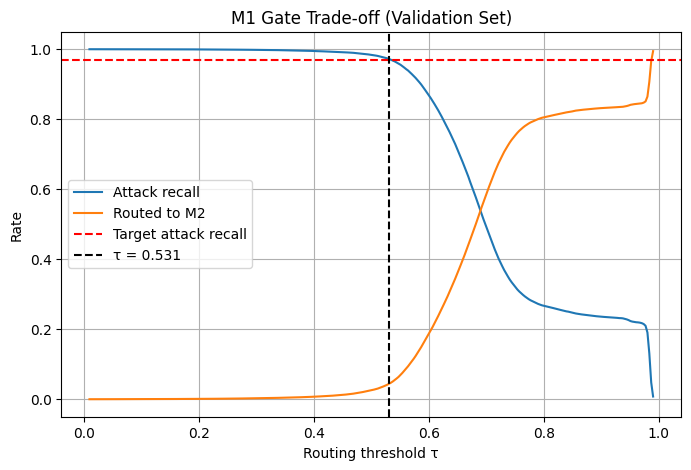

In [9]:
# ------------------------------------------------------------
# 9) THRESHOLD TUNING FOR M1 GATE (VALIDATION ONLY)
# ------------------------------------------------------------
# Purpose:
# - Select routing threshold τ for M1
# - Enforce high attack recall (safety-first IDS design)
# - Increase utilisation of M2 where safely possible
#
# IMPORTANT:
# - Uses VALIDATION data only
# - M1 is a routing gate, NOT a classifier
# ------------------------------------------------------------

# M1 attack probabilities on validation set
p_attack_val = get_attack_prob(X_val)

# Candidate routing thresholds
taus = np.linspace(0.01, 0.99, 300)

records = []

# Sweep thresholds
for tau in taus:
    # Routing decisions
    to_attack = p_attack_val >= tau      # routed to M3
    to_non_attack = ~to_attack           # routed to M2

    # Routing metrics
    attack_recall = (to_attack & is_attack_val).sum() / is_attack_val.sum()
    nonattack_to_attack = (
        (to_attack & is_non_attack_val).sum() / is_non_attack_val.sum()
    )
    routed_to_M2 = to_non_attack.mean()

    records.append({
        "tau": tau,
        "attack_recall": attack_recall,
        "nonattack_to_attack": nonattack_to_attack,
        "routed_to_M2": routed_to_M2
    })

# Aggregate results
tuning_df = pd.DataFrame(records)

# ------------------------------------------------------------
# Choose operating point (recall-constrained optimisation)
# ------------------------------------------------------------
# Design principle:
# τ is NOT selected to optimise accuracy or F1.
# It is selected to satisfy a safety constraint on attack recall.
# ------------------------------------------------------------

TARGET_RECALL = 0.97   # increase to 0.99 for stricter safety

# Keep only thresholds that satisfy recall constraint
candidates = tuning_df[tuning_df["attack_recall"] >= TARGET_RECALL]

if len(candidates) == 0:
    raise RuntimeError("No threshold satisfies the required attack recall.")

# Among safe thresholds, minimise non-attack routing to M3
best = (
    candidates
    .sort_values(["nonattack_to_attack", "tau"])
    .iloc[0]
)

# Fix routing threshold for deployment
TAU_GATE = float(best["tau"])

# Report chosen operating point
print("Chosen τ:", TAU_GATE)
print("Attack recall:", best["attack_recall"])
print("Non-attacks sent to M3:", best["nonattack_to_attack"])
print("Routed to M2:", best["routed_to_M2"])
print(
    "\nNote: τ is selected to prioritise attack recall. "
    "False positives are expected and handled by downstream classifiers."
)
# ------------------------------------------------------------
# Visualise trade-off
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(tuning_df["tau"], tuning_df["attack_recall"], label="Attack recall")
plt.plot(tuning_df["tau"], tuning_df["routed_to_M2"], label="Routed to M2")

plt.axhline(
    TARGET_RECALL,
    color="red",
    linestyle="--",
    label="Target attack recall"
)
plt.axvline(
    TAU_GATE,
    color="black",
    linestyle="--",
    label=f"τ = {TAU_GATE:.3f}"
)

plt.xlabel("Routing threshold τ")
plt.ylabel("Rate")
plt.title("M1 Gate Trade-off (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# ------------------------------------------------------------
# 10) M1 GATE EVALUATION (TEST SET ONLY)
# ------------------------------------------------------------
# Purpose:
# - Evaluate routing behaviour of M1 using the FIXED threshold τ
# - Compare routing decisions against true attack / non-attack labels
# - No tuning or threshold adjustment is allowed in this cell
#
# IMPORTANT:
# - τ is fixed from validation (Cell 9)
# - This is a pure generalisation test
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------------------------------------
# Compute M1 attack probabilities (test set)
# ------------------------------------------------------------
p_attack_test = get_attack_prob(X_test)

# Routing decisions using fixed τ
m1_route_test = np.where(
    p_attack_test >= TAU_GATE,
    "Attack",
    "Non-Attack"
)

# Ground-truth routing labels (system-level)
true_route_test = np.where(
    y_test.isin(NON_ATTACK_IDS),
    "Non-Attack",
    "Attack"
)

# ------------------------------------------------------------
# Routing confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(
    true_route_test,
    m1_route_test,
    labels=["Attack", "Non-Attack"]
)

print("M1 Routing Confusion Matrix (TEST SET)")
print(cm)

# NOTE:
# The following classification report is shown for completeness.
# M1 is a routing gate, not a final classifier.
# Precision/recall imbalance is expected due to recall-constrained design.
print("\nM1 Routing Classification Report (TEST SET)")
print(
    classification_report(
        true_route_test,
        m1_route_test,
        target_names=["Attack", "Non-Attack"]
    )
)

# ------------------------------------------------------------
# Key gate metrics (explicit and interpretable)
# ------------------------------------------------------------
is_attack = (true_route_test == "Attack")
routed_attack = (m1_route_test == "Attack")

attack_routing_recall = (routed_attack & is_attack).sum() / is_attack.sum()
missed_attacks = (~routed_attack & is_attack).sum()
false_alarm_rate = (routed_attack & ~is_attack).mean()

# Note:
# Low non-attack recall is expected because the gate is recall-constrained.
# Non-attacks misrouted to M3 are handled by downstream classifiers or fallback.

print("\nM1 Gate Metrics (TEST SET)")
print(f"τ (routing threshold): {TAU_GATE:.4f}")
print(f"Attack routing recall: {attack_routing_recall:.4f}")
print(f"Missed attacks: {missed_attacks}")
print(f"False alarm rate (non-attacks → M3): {false_alarm_rate:.4f}")
print(f"Routed to M3 (%): {np.mean(routed_attack):.4f}")
print(f"Routed to M2 (%): {1 - np.mean(routed_attack):.4f}")

M1 Routing Confusion Matrix (TEST SET)
[[10782   350]
 [ 4168   376]]

M1 Routing Classification Report (TEST SET)
              precision    recall  f1-score   support

      Attack       0.72      0.97      0.83     11132
  Non-Attack       0.52      0.08      0.14      4544

    accuracy                           0.71     15676
   macro avg       0.62      0.53      0.48     15676
weighted avg       0.66      0.71      0.63     15676


M1 Gate Metrics (TEST SET)
τ (routing threshold): 0.5311
Attack routing recall: 0.9686
Missed attacks: 350
False alarm rate (non-attacks → M3): 0.2659
Routed to M3 (%): 0.9537
Routed to M2 (%): 0.0463


## Summary of M1 Routing Performance (Test Set)

The table below summarises the **system-level routing behaviour** of M1 on the held-out test set using the **fixed threshold τ** selected from validation data.

| Metric | Description | Value |
|------|------------|-------|
| Routing Threshold (τ) | Fixed attack probability threshold | τ = {TAU_GATE:.4f} |
| Attack Routing Recall | Fraction of true attacks correctly routed to attack branch | {attack_routing_recall:.4f} |
| Missed Attacks | Number of attacks incorrectly routed as non-attack | {missed_attacks} |
| False Alarm Rate | Fraction of non-attacks routed to attack branch | {false_alarm_rate:.4f} |
| Samples Routed to Attack Branch | Proportion of test samples sent to M3 | {np.mean(routed_attack):.4f} |
| Samples Routed to Non-Attack Branch | Proportion of test samples sent to M2 | {1 - np.mean(routed_attack):.4f} |

**Notes:**
- M1 is a **routing gate**, not a final classifier.
- High attack routing recall is prioritised by design.
- Non-attack samples misrouted to the attack branch are handled by downstream classifiers in the full system.

## Conclusion

This notebook evaluated the **generalisation performance of M1**, the front-end routing gate in a hierarchical intrusion detection system (IDS).

Using a **fixed routing threshold τ**, selected exclusively on validation data, M1 demonstrates stable and interpretable routing behaviour on the test set. The results confirm that M1 reliably prioritises **attack detection**, accepting a controlled increase in false alarms as an intentional trade-off consistent with safety-critical IDS requirements.

The analysis validates M1 as an effective **selective decision gate** that:
- Separates attack and non-attack events at the system level
- Enables conditional downstream classification
- Preserves interpretability and modularity in the overall IDS architecture

Evaluation of downstream classifiers (M2–M6) and full end-to-end system performance is conducted in separate notebooks.

In [11]:
print(X.columns)

Index(['R1-PA1:VH', 'R1-PM1:V', 'R1-PA2:VH', 'R1-PM2:V', 'R1-PA3:VH',
       'R1-PM3:V', 'R1-PA4:IH', 'R1-PM4:I', 'R1-PA5:IH', 'R1-PM5:I',
       ...
       'relay3_log', 'relay4_log', 'snort_log1', 'snort_log2', 'snort_log3',
       'snort_log4', 'R1-PA:Z_inf_flag', 'R2-PA:Z_inf_flag',
       'R3-PA:Z_inf_flag', 'R4-PA:Z_inf_flag'],
      dtype='object', length=132)
